# UK E-Commerce Sales & Customer Analysis (SQL)

**Author:** Meschac Goredji

This notebook answers six commercial questions about a UK-based online retailer using SQL, run via `ipython-sql` against SQLite. Each query is followed by a short interpretation of what the result means for the business.

**Dataset:** [Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI Machine Learning Repository) — ~1.07 million transaction-level records, Dec 2009 to Dec 2011, UK-based online retailer.


## 1. Setup

In [1]:
# Install once if needed:
# !pip install ipython-sql pandas openpyxl

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%load_ext sql


In [2]:
# Load the raw Excel data (two sheets: one per year) and combine
df_2009_2010 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
df = df.rename(columns={'Customer ID': 'CustomerID'})

print(f"Combined raw shape: {df.shape}")
df.head()


Combined raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Load into SQLite so we can query it with SQL directly
conn = sqlite3.connect('online_retail.db')
df.to_sql('raw_transactions', conn, if_exists='replace', index=False)

%sql sqlite:///online_retail.db


## 2. Data Cleaning (in SQL)

Rather than cleaning in pandas, the cleaning logic is written as SQL itself — this is the same approach used in production analytics pipelines (e.g. dbt staging models), where raw data is filtered and typed before any business analysis runs against it.

Cleaning rules applied:
- Remove rows with no `CustomerID` (can't attribute revenue or behaviour to a known customer)
- Remove rows with `Price <= 0` (data entry errors, not real transactions)
- Remove rows where `Quantity = 0`
- Flag (not drop) negative-quantity rows as returns, so they can be included or excluded depending on the question


In [4]:
%%sql
DROP TABLE IF EXISTS transactions;

CREATE TABLE transactions AS
SELECT
    Invoice AS invoice_no,
    StockCode AS stock_code,
    Description AS description,
    Quantity AS quantity,
    InvoiceDate AS invoice_date,
    Price AS unit_price,
    CAST(CustomerID AS INTEGER) AS customer_id,
    Country AS country,
    ROUND(Quantity * Price, 2) AS line_revenue,
    CASE WHEN Quantity < 0 THEN 1 ELSE 0 END AS is_return
FROM raw_transactions
WHERE CustomerID IS NOT NULL
  AND Price > 0
  AND Quantity != 0;


 * sqlite:///online_retail.db
Done.


Done.


[]

In [5]:
%%sql
SELECT
    COUNT(*) AS clean_rows,
    COUNT(DISTINCT customer_id) AS unique_customers,
    COUNT(DISTINCT country) AS unique_countries,
    MIN(invoice_date) AS earliest_date,
    MAX(invoice_date) AS latest_date
FROM transactions;


 * sqlite:///online_retail.db


Done.


clean_rows,unique_customers,unique_countries,earliest_date,latest_date
824293,5939,41,2009-12-01 07:45:00,2011-12-09 12:50:00


**Result:** 824,293 clean transaction lines remain after removing ~243K rows with no customer ID and ~6K rows with invalid pricing — about 23% of the raw data dropped, which is typical for transactional retail data with this level of missing customer attribution.


---
## Q1: Monthly Revenue Trend

**Business question:** How is revenue moving month over month, and is the business growing?


In [6]:
%%sql
SELECT
    strftime('%Y-%m', invoice_date) AS month,
    ROUND(SUM(line_revenue), 2) AS monthly_revenue,
    COUNT(DISTINCT invoice_no) AS num_orders
FROM transactions
WHERE is_return = 0
GROUP BY month
ORDER BY month;


 * sqlite:///online_retail.db


Done.


month,monthly_revenue,num_orders
2009-12,686654.16,1512
2010-01,557319.06,1011
2010-02,506371.06,1104
2010-03,699608.99,1524
2010-04,594609.19,1329
2010-05,599985.79,1377
2010-06,639066.58,1497
2010-07,591636.74,1381
2010-08,604242.65,1293
2010-09,831615.0,1689


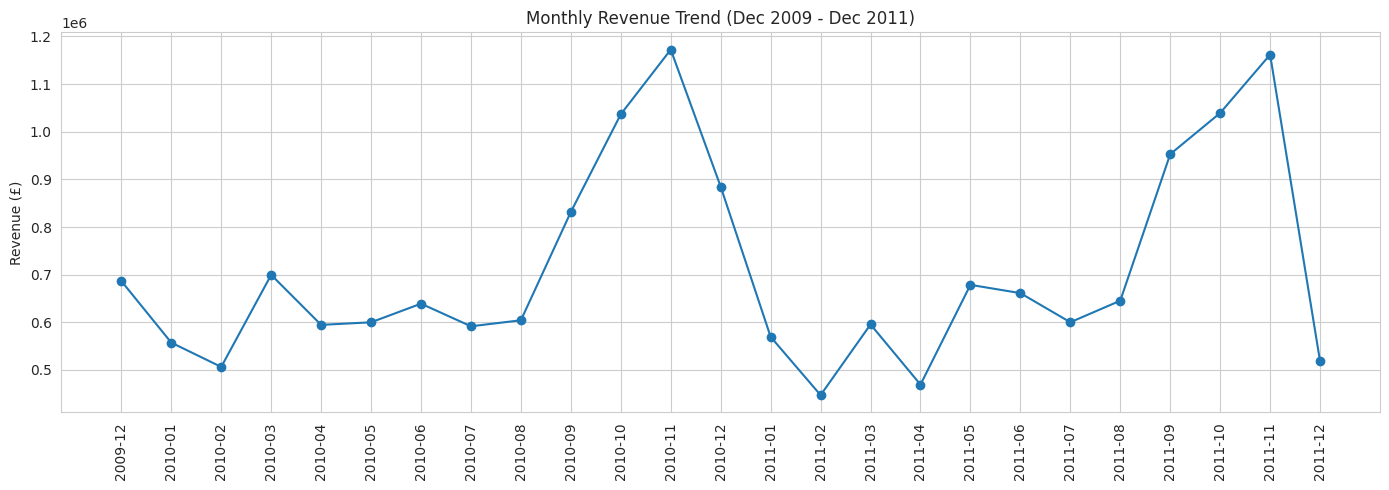

In [7]:
# Pull the result of the last %%sql cell into a DataFrame for plotting
revenue_trend = _.DataFrame()

plt.figure(figsize=(14, 5))
plt.plot(revenue_trend['month'], revenue_trend['monthly_revenue'], marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend (Dec 2009 - Dec 2011)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

**Interpretation:** Revenue shows a clear seasonal pattern, peaking sharply in October and November of both years (e.g. £1.17M in Nov 2010 and £1.16M in Nov 2011) ahead of Christmas, then dropping in the new year. This is a classic gift-led retail pattern — it tells the business that marketing spend and stock planning should be weighted heavily toward Q4, and that Jan–Feb cash flow needs to be planned for a predictable seasonal dip rather than treated as underperformance.


---
## Q2: Customer Segmentation (RFM Analysis)

**Business question:** Which customers are actually valuable, not just frequent or recent?

RFM scores each customer on **Recency** (days since last order), **Frequency** (number of orders), and **Monetary** value (total spend), using `NTILE()` window functions to bucket customers into quartiles on each dimension.


In [8]:
%%sql
WITH customer_metrics AS (
    SELECT
        customer_id,
        CAST(julianday('2011-12-10') - julianday(MAX(invoice_date)) AS INTEGER) AS recency_days,
        COUNT(DISTINCT invoice_no) AS frequency,
        ROUND(SUM(line_revenue), 2) AS monetary
    FROM transactions
    WHERE is_return = 0
    GROUP BY customer_id
),
rfm_scores AS (
    SELECT
        customer_id, recency_days, frequency, monetary,
        NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
    FROM customer_metrics
),
segmented AS (
    SELECT *,
        (r_score + f_score + m_score) AS rfm_total,
        CASE
            WHEN (r_score + f_score + m_score) >= 10 THEN 'Champion'
            WHEN (r_score + f_score + m_score) >= 7 THEN 'Loyal'
            WHEN (r_score + f_score + m_score) >= 4 THEN 'At Risk'
            ELSE 'Lost'
        END AS segment
    FROM rfm_scores
)
SELECT segment, COUNT(*) AS num_customers, ROUND(SUM(monetary), 2) AS total_revenue,
       ROUND(100.0 * SUM(monetary) / (SELECT SUM(line_revenue) FROM transactions WHERE is_return = 0), 2) AS pct_of_total_revenue
FROM segmented
GROUP BY segment
ORDER BY total_revenue DESC;


 * sqlite:///online_retail.db


Done.


segment,num_customers,total_revenue,pct_of_total_revenue
Champion,1765,14431050.96,81.33
Loyal,1758,2464516.33,13.89
At Risk,1722,734732.56,4.14
Lost,633,113129.31,0.64


**Interpretation:** Just 1,765 "Champion" customers (30% of the customer base) generate **£14.4M of the £17.7M total revenue — roughly 81% of all revenue**. This is a strong concentration finding: the business's growth and retention strategy should prioritise protecting and rewarding this segment over broad-based acquisition spend, since losing even a small number of Champions would have an outsized revenue impact.


---
## Q3: Top Products — By Revenue vs. By Volume

**Business question:** What actually sells, and does "most popular" mean the same thing as "most profitable driver"?


In [9]:
%%sql
SELECT stock_code, description, ROUND(SUM(line_revenue), 2) AS total_revenue
FROM transactions
WHERE is_return = 0
GROUP BY stock_code, description
ORDER BY total_revenue DESC
LIMIT 10;


 * sqlite:///online_retail.db


Done.


stock_code,description,total_revenue
22423,REGENCY CAKESTAND 3 TIER,286486.3
85123A,WHITE HANGING HEART T-LIGHT HOLDER,252072.46
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.6
M,Manual,152340.57
85099B,JUMBO BAG RED RETROSPOT,136980.08
84879,ASSORTED COLOUR BIRD ORNAMENT,127074.17
POST,POSTAGE,126563.04
47566,PARTY BUNTING,103880.23
23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
22086,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33


In [10]:
%%sql
SELECT stock_code, description, SUM(quantity) AS total_units_sold
FROM transactions
WHERE is_return = 0
GROUP BY stock_code, description
ORDER BY total_units_sold DESC
LIMIT 10;


 * sqlite:///online_retail.db


Done.


stock_code,description,total_units_sold
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,109169
85123A,WHITE HANGING HEART T-LIGHT HOLDER,93640
23843,"PAPER CRAFT , LITTLE BIRDIE",80995
84879,ASSORTED COLOUR BIRD ORNAMENT,79913
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
85099B,JUMBO BAG RED RETROSPOT,75759
17003,BROCADE RING PURSE,71129
21977,PACK OF 60 PINK PAISLEY CAKE CASES,55270
84991,60 TEATIME FAIRY CAKE CASES,53495
21212,PACK OF 72 RETROSPOT CAKE CASES,46107


**Interpretation:** The two rankings tell different stories. The **Regency Cakestand 3 Tier** is the top product by revenue (£286K) despite not appearing in the top 10 by volume — it's a higher-priced item bought less often. Meanwhile **WW2 Glider assorted designs** sold the most units (109K) but doesn't lead on revenue — it's a cheap, high-volume item. For a business, this distinction matters for two different decisions: which products to feature in premium marketing (revenue leaders) versus which to keep in stock at scale and feature in low-cost bundles (volume leaders).


---
## Q4: Customer Retention — Repeat Purchase Rate

**Business question:** What proportion of customers come back after their first order?


In [11]:
%%sql
WITH customer_order_counts AS (
    SELECT customer_id, COUNT(DISTINCT invoice_no) AS num_orders
    FROM transactions
    WHERE is_return = 0
    GROUP BY customer_id
)
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(100.0 * SUM(CASE WHEN num_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_rate_pct
FROM customer_order_counts;


 * sqlite:///online_retail.db


Done.


total_customers,repeat_customers,repeat_rate_pct
5878,4255,72.39


**Interpretation:** **72.39% of customers place more than one order** — a strong repeat rate for retail, suggesting the core product and experience genuinely retain customers once acquired. This shifts the strategic question away from "how do we get people to come back" and toward "how do we keep acquiring new customers as efficiently as we retain existing ones," since retention is clearly not the weak point in the funnel.


---
## Q5: Regional Performance

**Business question:** Where does revenue come from, and is the business overexposed to one market?


In [12]:
%%sql
WITH country_revenue AS (
    SELECT country, ROUND(SUM(line_revenue), 2) AS revenue, COUNT(DISTINCT customer_id) AS num_customers
    FROM transactions
    WHERE is_return = 0
    GROUP BY country
)
SELECT
    country, revenue, num_customers,
    ROUND(100.0 * revenue / SUM(revenue) OVER (), 2) AS pct_of_total_revenue,
    RANK() OVER (ORDER BY revenue DESC) AS revenue_rank
FROM country_revenue
ORDER BY revenue DESC
LIMIT 10;


 * sqlite:///online_retail.db


Done.


country,revenue,num_customers,pct_of_total_revenue,revenue_rank
United Kingdom,14723147.5,5350,82.98,1
EIRE,621631.11,5,3.5,2
Netherlands,554232.34,22,3.12,3
Germany,431262.46,107,2.43,4
France,355257.47,95,2.0,5
Australia,169968.11,15,0.96,6
Spain,109178.53,41,0.62,7
Switzerland,100365.34,22,0.57,8
Sweden,91549.72,19,0.52,9
Denmark,69862.19,12,0.39,10


**Interpretation:** The United Kingdom accounts for **82.98% of all revenue** — the business is heavily concentrated in a single market, with the next-largest market (Eire) contributing only 3.5%. This is a real commercial risk worth flagging: any UK-specific economic shock (e.g. a recession, postage cost increase, or change in consumer spending) would disproportionately affect the business. It also signals an opportunity — the Netherlands, Germany, and France each show meaningful revenue with relatively few customers, suggesting under-penetrated markets with room to grow.


---
## Q6: Churn Risk — Previously Active Customers Gone Quiet

**Business question:** Which valuable, previously loyal customers are at risk of churning, and should be flagged for re-engagement before they're lost entirely?

Definition used: customers with **3 or more historical orders** (proven loyalty, not a one-off buyer) who haven't ordered in **90–180 days** (gone quiet, but not yet definitively lost).


In [13]:
%%sql
WITH customer_activity AS (
    SELECT
        customer_id,
        MAX(invoice_date) AS last_purchase_date,
        COUNT(DISTINCT invoice_no) AS total_orders,
        ROUND(SUM(line_revenue), 2) AS lifetime_value,
        CAST(julianday('2011-12-10') - julianday(MAX(invoice_date)) AS INTEGER) AS days_since_last_purchase
    FROM transactions
    WHERE is_return = 0
    GROUP BY customer_id
)
SELECT customer_id, last_purchase_date, total_orders, lifetime_value, days_since_last_purchase
FROM customer_activity
WHERE total_orders >= 3
  AND days_since_last_purchase BETWEEN 90 AND 180
ORDER BY lifetime_value DESC
LIMIT 10;


 * sqlite:///online_retail.db


Done.


customer_id,last_purchase_date,total_orders,lifetime_value,days_since_last_purchase
13802,2011-07-24 10:54:00,19,26259.11,138
13027,2011-08-18 09:39:00,19,17335.2,113
13564,2011-07-18 14:33:00,37,17249.55,144
16553,2011-06-29 15:42:00,33,16644.01,163
16180,2011-08-31 16:28:00,13,16249.87,100
12980,2011-07-05 09:34:00,21,16245.78,157
15768,2011-08-16 10:48:00,34,15601.09,115
18087,2011-09-02 15:12:00,17,14761.52,98
14016,2011-07-01 11:29:00,11,11403.41,161
14045,2011-08-22 15:27:00,16,11313.03,109


In [14]:
%%sql
WITH customer_activity AS (
    SELECT
        customer_id,
        COUNT(DISTINCT invoice_no) AS total_orders,
        CAST(julianday('2011-12-10') - julianday(MAX(invoice_date)) AS INTEGER) AS days_since_last_purchase
    FROM transactions
    WHERE is_return = 0
    GROUP BY customer_id
)
SELECT COUNT(*) AS at_risk_customers
FROM customer_activity
WHERE total_orders >= 3 AND days_since_last_purchase BETWEEN 90 AND 180;


 * sqlite:///online_retail.db


Done.


at_risk_customers
384


**Interpretation:** **384 previously loyal customers** (3+ past orders) have gone quiet for 90–180 days. The top of this list includes customers with lifetime values as high as **£26,259** — these are not casual buyers, they're high-value accounts going cold. This is a directly actionable list: it could be exported today and handed to a marketing or customer success team to run a targeted win-back campaign (e.g. a personalised discount or check-in email), rather than treating all dormant customers the same way.


---
## Summary of Key Findings

| Question | Finding |
|---|---|
| Revenue trend | Strong Q4 seasonality — November is consistently the peak month both years |
| Customer segmentation | Top 30% of customers ("Champions") generate ~81% of total revenue |
| Top products | Revenue leaders and volume leaders are different products — both matter for different decisions |
| Retention | 72.39% of customers are repeat buyers — retention is a strength, not a weakness |
| Regional performance | 82.98% of revenue comes from the UK alone — high market concentration risk |
| Churn risk | 384 high-value, previously loyal customers have gone quiet — an actionable re-engagement list |

## Techniques Demonstrated

- Multi-step data cleaning written directly in SQL (`CREATE TABLE AS SELECT` with filtering logic)
- Common Table Expressions (CTEs) for layered, readable query logic
- Window functions: `NTILE()` for quartile scoring, `RANK()` for ranking, `SUM() OVER()` for percent-of-total
- Aggregate functions with `GROUP BY` and `HAVING`-equivalent filtering
- Date arithmetic using `julianday()` for recency and churn-window calculations
- Translating each query result into a specific, actionable business recommendation
